# Examen Python data developer
# Deel 1
## Introductie
Voor dit examen is het belangrijk dat je volgende zaken zeker doet:
 - Maak een Vitual Environment aan & exporteer een `.yml` (of soortgelijke) file aan die je toevoegt aan je codebase.
 - Maak een github pagina aan met een bijhorende `.gitignore` en `readme.md`. Voeg een link naar de github repo toe aan je readme file.
 - Zorg dat je op het einde de tijd neemt om je code op te schonen zodat deze begrijpelijk is voor derden.
 - Wanneer je klaar bent, maak een `.zip` bestand van je volledige codebase aan en laad deze op in de leeromgeving.

In deze opgave bekijken we een gesimuleerde dataset over de geboortes in België van 2019. De data is te vinden in `.csv` bestanden die gelabeld zijn met de echte geboortedag van de personen in het bestand. Laat ons bijvoorbeeld even kijken naar de eerste 5 lijnen van het bestand `2019-1-1.csv`:

<table align="center">
  <tr>
    <th>gemeente</th>
    <th>naam</th>
    <th>geslacht</th>
    <th>verwachte datum</th>
  </tr>
  <tr>
    <td>Hooglede</td>
    <td>Elias</td>
    <td>Mannelijk</td>
    <td>01/14/2019</td>
  </tr>
  <tr>
    <td>Sint-Niklaas (Sint-Niklaas)</td>
    <td>Pauline</td>
    <td>Vrouwelijk</td>
    <td>01/05/2019</td>
  </tr>
  <tr>
    <td>Wijnegem</td>
    <td>Anita</td>
    <td>Vrouwelijk</td>
    <td>01/05/2019</td>
  </tr>
  <tr>
    <td>Grâce-Hollogne</td>
    <td>Jean-Paul</td>
    <td>Mannelijk</td>
    <td>01/13/2019</td>
  </tr>
  <tr>
    <td>Boussu</td>
    <td>François</td>
    <td>Mannelijk</td>
    <td>01/26/2019</td>
  </tr>
</table>


Hier hebben we de kolommen:
 - **gemeente**: De gemeente waar de persoon geboren is.
 - **naam**: De voornaam van de persoon.
 - **geslacht**: Het geslacht van de persoon (Mannelijk of Vrouwelijk).
 - **verwachte datum**: De verwachte geboortedatum van de persoon.

Dus hier hebben we dan bijvoorbeeld op de eerste lijn de mannelijke persoon Elias die geboren is in Hooglede waarvan men verwachtte dat hij zou geboren worden op `01/14/2019` (Amerikaans formaat) maar in feite geboren is op 1 januari 2019.

Doorheen deze opgave gaan we de data van dichterbij inspecteren! Je kan deze opgaves alternatief lezen in de bijgeleverde notebook `examen.ipynb` waar ook de (meeste) afbeeldingen & resultaten zichtbaar zijn.

## Visualisaties

Wanneer er je gevraagd wordt een visualisatie te maken krijg je minimale instructies. Tijdens de lessenreeks zagen we een heel aantal best practices, pas deze toe ook al wordt dit niet telkens expliciet aangegeven in de instructies.


## Puntenverdeling
**Het totale examen staat op X punten.**

Mondelinge toelichting voor alles
 - 50%: Je snapt wat je gedaan hebt.
 - 50%: Je kan bijvragen beantwoorden

## Utilities

In [19]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [178]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date
from pathlib import Path
import matplotlib.ticker as mticker

from syntradsexamen.config import DATA_DIR, YEAR, COL_GEMEENTE, COL_NAAM, COL_GESLACHT, COL_VERWACHTE_DATUM, COL_GEBOORTEDATUM, COL_DAG_VAN_HET_JAAR

from syntradsexamen.styling import MEAN_COLOR, MEDIAN_COLOR, P25_COLOR, GRAY, TAN, SAGE, GOLDENROD, SLATE, ROSY, OLIVE, BROWN, CADET, PALETTE, standard_style

In [179]:
standard_style()

## Stap 1: data inlezen (1 pnt)

Bouw één DataFrame `df_births` met alle geboortes uit de map `data/geboortes`.

**Output**
- `df_births` bevat alle rijen uit alle CSV-bestanden.
- `df_births` bevat een kolom `date` als echte datetime (`YYYY-MM-DD`), afgeleid uit de bestandsnaam.
- `df_births` bevat een kolom `dag_van_jaar` met waarden van 1 tot 365.
- De observatie-grain is identiek aan de bron: **1 rij = 1 geboorte**.

**Te tonen checks**
- Aantal rijen in `df_births`
- Minimum- en maximumdatum
- Minimum en maximum van `day_of_year`
- Geen onbestaande datums (bv. dag 0, dag 32, 29/2 in niet-schrikkeljaren, geboortejaar 2027,...)

---

In [181]:
loaded_files = []
skipped_files = []
frames = []

for csv_path in sorted(DATA_DIR.glob("*.csv")):
    stem = csv_path.stem    # stem is het naamgedeelte van de filename, bv "2019-1-1"
    parts = stem.split("-") # split het stemgedeelte op - 

    # Must have exactly 3 parts: YYYY-M-D
    if len(parts) != 3:
        skipped_files.append(csv_path.name)
        continue

    # Try to build a valid date
    try:
        y, m, d = int(parts[0]), int(parts[1]), int(parts[2])
        geboortedatum = date(y, m, d)
    except (ValueError, IndexError):
        skipped_files.append(csv_path.name)
        continue

    # Only keep year 2019
    if y != YEAR:
        skipped_files.append(csv_path.name)
        continue

    # Read the CSV
    df_tmp = pd.read_csv(csv_path, encoding="utf-8-sig")

    # Rename "verwachte datum" → "verwachte_datum"
    df_tmp = df_tmp.rename(columns={"verwachte datum": COL_VERWACHTE_DATUM})

    # Add columns from filename
    df_tmp[COL_GEBOORTEDATUM] = pd.Timestamp(geboortedatum)
    df_tmp[COL_DAG_VAN_HET_JAAR] = geboortedatum.timetuple().tm_yday

    frames.append(df_tmp)
    loaded_files.append(csv_path.name)

df_births = pd.concat(frames, ignore_index=True)

# Parse verwachte_datum to datetime
df_births[COL_VERWACHTE_DATUM] = pd.to_datetime(
    df_births[COL_VERWACHTE_DATUM], format="mixed", dayfirst=False
)

print(f"Loaded: {len(loaded_files)} files")
print(f"Skipped: {len(skipped_files)} files: {skipped_files}")
print(f"Total rows: {len(df_births):,}")
df_births.head()

Loaded: 365 files
Skipped: 2 files: ['2019-2-29.csv', 'output_all.csv']
Total rows: 116,850


,gemeente,naam,geslacht,verwachte_datum,geboortedatum,dag_van_jaar
0,Hooglede,Elias,Mannelijk,2019-01-14,2019-01-01,1
1,Sint-Niklaas (Sint-Niklaas),Pauline,Vrouwelijk,2019-01-05,2019-01-01,1
2,Wijnegem,Anita,Vrouwelijk,2019-01-05,2019-01-01,1
3,Grâce-Hollogne,Jean-Paul,Mannelijk,2019-01-13,2019-01-01,1
4,Boussu,François,Mannelijk,2019-01-26,2019-01-01,1


In [182]:
# ── Checks ──────────────────────────────────────────────────────────────
print(f"Aantal rijen:           {len(df_births):,}")
print(f"Min geboortedatum:      {df_births[COL_GEBOORTEDATUM].min().date()}")
print(f"Max geboortedatum:      {df_births[COL_GEBOORTEDATUM].max().date()}")
print(f"Min dag_van_het_jaar:   {df_births[COL_DAG_VAN_HET_JAAR].min()}")
print(f"Max dag_van_het_jaar:   {df_births[COL_DAG_VAN_HET_JAAR].max()}")
print(f"Unieke geboortedatums:  {df_births[COL_GEBOORTEDATUM].nunique()}")
print(f"Dtype geboortedatum:    {df_births[COL_GEBOORTEDATUM].dtype}")
print(f"Dtype verwachte_datum:  {df_births[COL_VERWACHTE_DATUM].dtype}")
print(f"Nulls verwachte_datum:  {df_births[COL_VERWACHTE_DATUM].isna().sum()}")

# Assertions
assert pd.api.types.is_datetime64_any_dtype(df_births[COL_GEBOORTEDATUM]), \
    "geboortedatum is geen datetime."
assert pd.api.types.is_datetime64_any_dtype(df_births[COL_VERWACHTE_DATUM]), \
    "verwachte_datum is geen datetime."
assert df_births[COL_GEBOORTEDATUM].dt.year.eq(YEAR).all(), \
    "Niet alle geboortedatums zijn in 2019."
assert df_births[COL_DAG_VAN_HET_JAAR].between(1, 365).all(), \
    "dag_van_het_jaar buiten bereik."
assert df_births[COL_GEBOORTEDATUM].notna().all(), \
    "Ontbrekende geboortedatums."
assert df_births[COL_VERWACHTE_DATUM].notna().all(), \
    "Ontbrekende verwachte_datums."

print("\nAlle checks geslaagd: \n- geboortedatum is datetime object \n- verwachte_datum is datetime object \n- alle geboortedatums in 2019 \n- dagen van het jaar tussen 1 en 365 \n- geen ontbrekende geboortedatums \n- geen ontbrekende verwachte_datums")

Aantal rijen:           116,850
Min geboortedatum:      2019-01-01
Max geboortedatum:      2019-12-31
Min dag_van_het_jaar:   1
Max dag_van_het_jaar:   365
Unieke geboortedatums:  365
Dtype geboortedatum:    datetime64[s]
Dtype verwachte_datum:  datetime64[ns]
Nulls verwachte_datum:  0

Alle checks geslaagd: 
- geboortedatum is datetime object 
- verwachte_datum is datetime object 
- alle geboortedatums in 2019 
- dagen van het jaar tussen 1 en 365 
- geen ontbrekende geboortedatums 
- geen ontbrekende verwachte_datums


## Stap 2: EDA

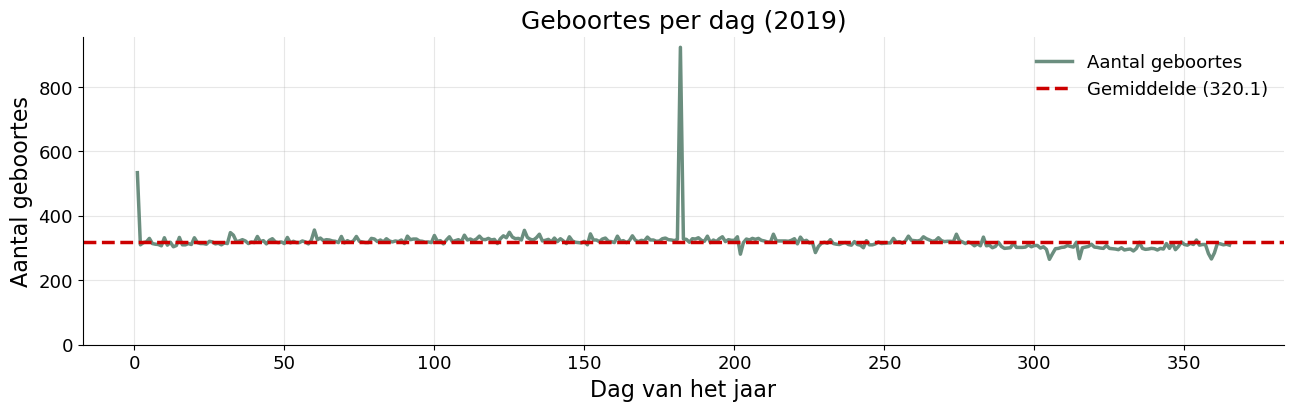

In [183]:
daily = (
    df_births
    .groupby("dag_van_jaar", as_index=False)
    .size()
    .rename(columns={"size": "geboortes"})
    .sort_values("dag_van_jaar")     
)

gemiddelde_geboortes = daily["geboortes"].mean()

fig, ax = plt.subplots(figsize=(15.5, 4))
ax.plot(daily["dag_van_jaar"], daily["geboortes"], label = "Aantal geboortes")

ax.set_title("Geboortes per dag (2019)")
ax.set_xlabel("Dag van het jaar")
ax.set_ylabel("Aantal geboortes")
ax.set_ylim(bottom=0)
ax.yaxis.set_major_locator(plt.MultipleLocator(200))
ax.grid(True, alpha=0.3)

# Horizontal dashed mean line
ax.axhline(
    y=gemiddelde_geboortes,
    color=MEAN_COLOR,
    linestyle="--",
    label=f"Gemiddelde ({gemiddelde_geboortes:.1f})"
)

ax.legend()
plt.show()

### Vraag 2: Outliers vinden & behandelen

#### Vraag 2.1 Zoek alle outliers in de dataset. (1 pnt)

Kies een regel om een datapunt als 'outlier' te classifieren, pas deze toe en verdedig je keuze.

In [184]:
# ── Outlier detectie met IQR ─────────────────────────────────────────────
# De IQR-methode bekijkt de verdeling van alle dagelijkse geboortecijfers.
# Q1 = 25e percentiel, Q3 = 75e percentiel, IQR = Q3 − Q1.
# Een dag is een outlier als het aantal geboortes buiten
# [Q1 − 1.5·IQR, Q3 + 1.5·IQR] valt.

Q1 = daily["geboortes"].quantile(0.25)
Q3 = daily["geboortes"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("── IQR-methode ──")
print(f"Q1:            {Q1:.1f}")
print(f"Q3:            {Q3:.1f}")
print(f"IQR:           {IQR:.1f}")
print(f"Ondergrens:    {lower_bound:.1f}")
print(f"Bovengrens:    {upper_bound:.1f}")

outliers_iqr = daily.loc[
    (daily["geboortes"] < lower_bound) | (daily["geboortes"] > upper_bound)
].copy()

# Voeg de datum toe voor leesbaarheid
dag_to_date = df_births[[COL_DAG_VAN_HET_JAAR, COL_GEBOORTEDATUM]].drop_duplicates()
outliers_iqr = outliers_iqr.merge(dag_to_date, on=COL_DAG_VAN_HET_JAAR)

# Sorteer op afstand tot mediaan (meest extreme bovenaan)
mediaan = daily["geboortes"].median()
outliers_iqr["afstand"] = (outliers_iqr["geboortes"] - mediaan).abs()
outliers_iqr = outliers_iqr.sort_values("afstand", ascending=False)

print(f"\nAantal outliers: {len(outliers_iqr)}")
for _, row in outliers_iqr.iterrows():
    print(f"  {row[COL_GEBOORTEDATUM].date()} (dag {row[COL_DAG_VAN_HET_JAAR]}): "
          f"{row['geboortes']} geboortes  (afstand tot mediaan: {row['afstand']:.0f})")

# ── Conclusie ────────────────────────────────────────────────────────────
# De IQR-methode vindt meerdere outliers, maar 2 dagen springen er
# duidelijk bovenuit: zij hebben veruit de grootste afstand tot de mediaan.
# Deze 2 onderzoeken we verder in Q2.2.

top2 = sorted(outliers_iqr.head(2)[COL_GEBOORTEDATUM].tolist())

print(f"\nDe 2 meest extreme outliers:")
print(top2)

── IQR-methode ──
Q1:            311.0
Q3:            325.0
IQR:           14.0
Ondergrens:    290.0
Bovengrens:    346.0

Aantal outliers: 14
  2019-07-01 (dag 182): 923 geboortes  (afstand tot mediaan: 603)
  2019-01-01 (dag 1): 534 geboortes  (afstand tot mediaan: 214)
  2019-11-01 (dag 305): 265 geboortes  (afstand tot mediaan: 55)
  2019-12-25 (dag 359): 266 geboortes  (afstand tot mediaan: 54)
  2019-11-11 (dag 315): 267 geboortes  (afstand tot mediaan: 53)
  2019-07-21 (dag 202): 281 geboortes  (afstand tot mediaan: 39)
  2019-11-02 (dag 306): 282 geboortes  (afstand tot mediaan: 38)
  2019-12-24 (dag 358): 283 geboortes  (afstand tot mediaan: 37)
  2019-03-01 (dag 60): 356 geboortes  (afstand tot mediaan: 36)
  2019-05-10 (dag 130): 355 geboortes  (afstand tot mediaan: 35)
  2019-12-26 (dag 360): 285 geboortes  (afstand tot mediaan: 35)
  2019-08-15 (dag 227): 286 geboortes  (afstand tot mediaan: 34)
  2019-05-05 (dag 125): 349 geboortes  (afstand tot mediaan: 29)
  2019-02-01 

#### Vraag 2.2 Outlier remediation (1 pnt)
Je stelt vast dat twee dagen eruit springen als outliers. Corrigeer en voeg foute rijen toe aan `df_wrong` met een duidelijk omschreven reden. Documenteer in een comment welk patroon je opmerkte en  verdedig je correctiestrategie. Hermaak ten slotte de figuur uit Vraag 1 op basis van `df_births_clean`.


In [76]:
# ── Exploratie van de 2 outlier-dagen ────────────────────────────────────

outlier_dates_list = [pd.Timestamp("2019-01-01"), pd.Timestamp("2019-07-01")]

for od in outlier_dates_list:
    print(f"\n{'='*60}")
    print(f"  Onderzoek: {od.date()}")
    print(f"{'='*60}")
    
    dag = df_births[df_births[COL_GEBOORTEDATUM] == od]
    print(f"Aantal rijen: {len(dag)}")
    
    # ── Check 1: Exacte duplicaten (alle kolommen inclusief verwachte_datum) ──
    dupes_exact = dag[dag.duplicated(
        subset=[COL_NAAM, COL_GEMEENTE, COL_GESLACHT, COL_VERWACHTE_DATUM], keep=False
    )]
    print(f"\nCheck 1 — Exacte duplicaten (naam+gemeente+geslacht+verwachte_datum): {len(dupes_exact)} rijen")
    if len(dupes_exact) > 0:
        display(dupes_exact.sort_values([COL_NAAM, COL_GEMEENTE]).head(10))
    
    # ── Check 2: Duplicaten zonder verwachte_datum ──
    dupes_partial = dag[dag.duplicated(
        subset=[COL_NAAM, COL_GEMEENTE, COL_GESLACHT], keep=False
    )]
    print(f"Check 2 — Duplicaten (naam+gemeente+geslacht, zonder verwachte_datum): {len(dupes_partial)} rijen")
    if len(dupes_partial) > 0:
        display(dupes_partial.sort_values([COL_NAAM, COL_GEMEENTE]).head(10))

# ── Check 3: Gemeenschappelijke rijen tussen de 2 dagen ──
jan1 = df_births[df_births[COL_GEBOORTEDATUM] == pd.Timestamp("2019-01-01")]
jul1 = df_births[df_births[COL_GEBOORTEDATUM] == pd.Timestamp("2019-07-01")]
cols = [COL_NAAM, COL_GEMEENTE, COL_GESLACHT]
gemeenschappelijk = jan1[cols].merge(jul1[cols], on=cols, how="inner")

print(f"\n{'='*60}")
print(f"  Check 3: Rijen op BEIDE dagen (naam+gemeente+geslacht)")
print(f"{'='*60}")
print(f"Gemeenschappelijk: {len(gemeenschappelijk)} rijen")
print(f"(Te weinig om de hoge aantallen te verklaren)")


  Onderzoek: 2019-01-01
Aantal rijen: 534

Check 1 — Exacte duplicaten (naam+gemeente+geslacht+verwachte_datum): 0 rijen
Check 2 — Duplicaten (naam+gemeente+geslacht, zonder verwachte_datum): 0 rijen

  Onderzoek: 2019-07-01
Aantal rijen: 923

Check 1 — Exacte duplicaten (naam+gemeente+geslacht+verwachte_datum): 0 rijen
Check 2 — Duplicaten (naam+gemeente+geslacht, zonder verwachte_datum): 0 rijen

  Check 3: Rijen op BEIDE dagen (naam+gemeente+geslacht)
Gemeenschappelijk: 8 rijen
(Te weinig om de hoge aantallen te verklaren)


In [185]:
# ── Check 4: Vergelijking met naburige en "verwarde" dagen ───────────────
# Hypothese: misschien zitten rijen van andere dagen in de outlier-bestanden.
# We checken:
#   - Jul 1 vs Jan 7 (maand/dag inversie: 7/1 ↔ 1/7)
#   - Jan 1 vs Dec 31 (jaargrens)
#   - Jan 1 vs Jan 2, Jul 1 vs Jul 2 (naburige dagen)

cols = [COL_NAAM, COL_GEMEENTE, COL_GESLACHT]

vergelijkingen = [
    ("1 jul vs 7 jan (maand/dag swap)",   pd.Timestamp("2019-07-01"), pd.Timestamp("2019-01-07")),
    ("1 jan vs 31 dec (jaargrens)",       pd.Timestamp("2019-01-01"), pd.Timestamp("2019-12-31")),
    ("1 jan vs 2 jan (naburig)",          pd.Timestamp("2019-01-01"), pd.Timestamp("2019-01-02")),
    ("1 jul vs 2 jul (naburig)",          pd.Timestamp("2019-07-01"), pd.Timestamp("2019-07-02")),
]

for label, datum_a, datum_b in vergelijkingen:
    dag_a = df_births[df_births[COL_GEBOORTEDATUM] == datum_a]
    dag_b = df_births[df_births[COL_GEBOORTEDATUM] == datum_b]
    
    gemeenschappelijk = dag_a[cols].merge(dag_b[cols], on=cols, how="inner")
    
    print(f"{label}:")
    print(f"  {datum_a.date()} heeft {len(dag_a)} rijen, "
          f"{datum_b.date()} heeft {len(dag_b)} rijen")
    print(f"  Gemeenschappelijke rijen: {len(gemeenschappelijk)}")
    print()

1 jul vs 7 jan (maand/dag swap):
  2019-07-01 heeft 923 rijen, 2019-01-07 heeft 312 rijen
  Gemeenschappelijke rijen: 4

1 jan vs 31 dec (jaargrens):
  2019-01-01 heeft 534 rijen, 2019-12-31 heeft 309 rijen
  Gemeenschappelijke rijen: 2

1 jan vs 2 jan (naburig):
  2019-01-01 heeft 534 rijen, 2019-01-02 heeft 310 rijen
  Gemeenschappelijke rijen: 5

1 jul vs 2 jul (naburig):
  2019-07-01 heeft 923 rijen, 2019-07-02 heeft 328 rijen
  Gemeenschappelijke rijen: 3



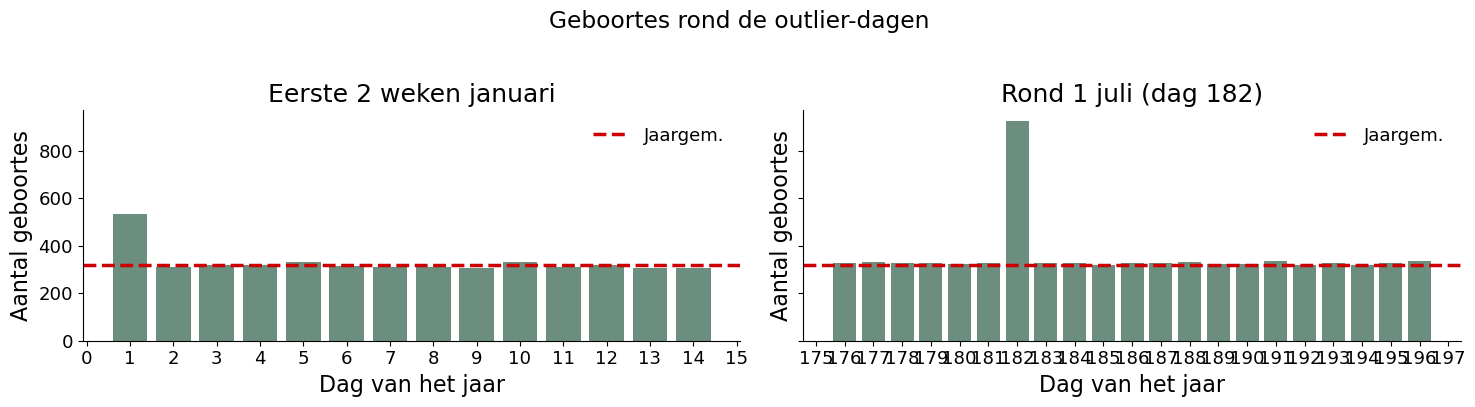

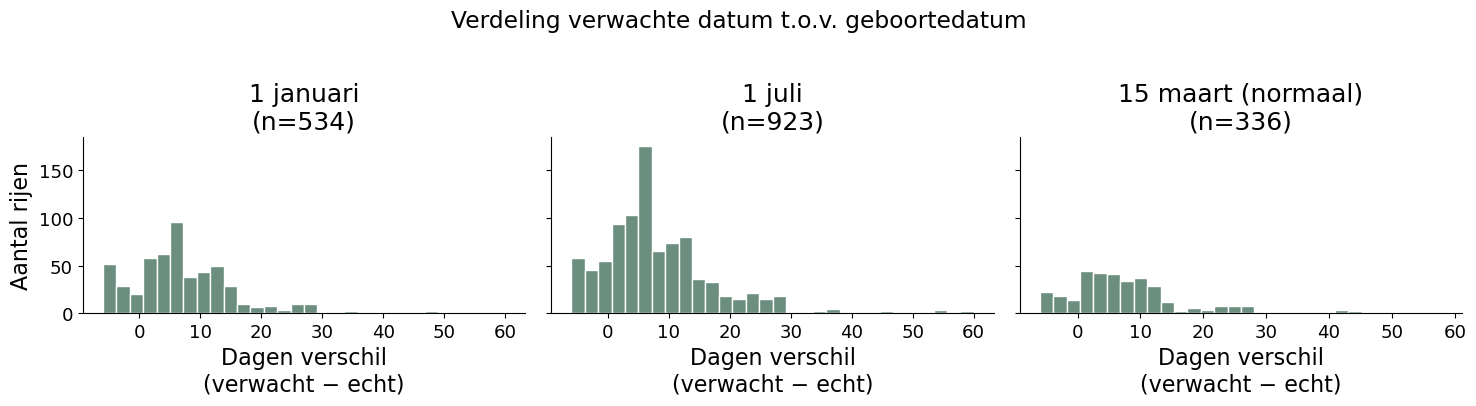

In [186]:
# ── Visualisatie 1: geboortes per dag rond de outliers ────────────────────
# Als rijen van naburige dagen naar 1 jan / 1 jul verschoven zijn,
# zien we een piek op de outlier en een dal eromheen.

fig, axes = plt.subplots(1, 2, figsize=(15, 4), sharey=True)

for ax, (start, end, title) in zip(axes, [
    (1, 14, "Eerste 2 weken januari"),
    (176, 196, "Rond 1 juli (dag 182)"),
]):
    subset = daily[(daily["dag_van_jaar"] >= start) & (daily["dag_van_jaar"] <= end)]
    ax.bar(subset["dag_van_jaar"], subset["geboortes"], color=SAGE)
    ax.axhline(gemiddelde_geboortes, color=MEAN_COLOR, linestyle="--", label="Jaargem.")
    ax.set_title(title)
    ax.set_xlabel("Dag van het jaar")
    ax.set_ylabel("Aantal geboortes")
    ax.xaxis.set_major_locator(plt.MultipleLocator(1))
    ax.legend()

plt.suptitle("Geboortes rond de outlier-dagen", y=1.02)
plt.tight_layout()
plt.show()

# ── Visualisatie 2: verdeling verwachte_datum op outlier vs normale dag ──
# Als de outlier-dag "vreemde" rijen bevat, ziet de verwachte_datum
# verdeling er anders uit dan op een normale dag.

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

normal_day = pd.Timestamp("2019-03-15")

for ax, (lbl, geboortedatum) in zip(axes, [
    ("1 januari", pd.Timestamp("2019-01-01")),
    ("1 juli", pd.Timestamp("2019-07-01")),
    ("15 maart (normaal)", normal_day),
]):
    dag = df_births[df_births[COL_GEBOORTEDATUM] == geboortedatum]
    verschil = (dag[COL_VERWACHTE_DATUM] - dag[COL_GEBOORTEDATUM]).dt.days
    ax.hist(verschil, bins=30, color=SAGE, edgecolor="white")
    ax.set_title(f"{lbl}\n(n={len(dag)})")
    ax.set_xlabel("Dagen verschil\n(verwacht − echt)")
    ax.xaxis.set_major_locator(plt.MultipleLocator(10))

axes[0].set_ylabel("Aantal rijen")
plt.suptitle("Verdeling verwachte datum t.o.v. geboortedatum", y=1.02)
plt.tight_layout()
plt.show()

In [187]:
# ── Check 5: Komen rijen op de outlier-dagen ook voor op ANDERE dagen? ───
# Voor elke rij op Jan 1 / Jul 1: zoek een exacte match (alle 4 kolommen)
# ergens anders in de dataset. Als die bestaat, is de rij waarschijnlijk
# een duplicaat dat van die andere dag komt.

match_cols = [COL_NAAM, COL_GEMEENTE, COL_GESLACHT, COL_VERWACHTE_DATUM]

for od in [pd.Timestamp("2019-01-01"), pd.Timestamp("2019-07-01")]:
    print(f"\n{'='*60}")
    print(f"  {od.date()}: rijen die ook op een ANDERE dag voorkomen")
    print(f"{'='*60}")
    
    # Rijen op de outlier-dag
    dag_outlier = df_births[df_births[COL_GEBOORTEDATUM] == od]
    # Alle rijen BEHALVE de outlier-dag
    rest = df_births[df_births[COL_GEBOORTEDATUM] != od]
    
    # Merge: welke rijen van de outlier-dag bestaan ook elders?
    matches = dag_outlier.merge(
        rest[match_cols + [COL_GEBOORTEDATUM]],
        on=match_cols,
        how="inner",
        suffixes=("_outlier", "_andere_dag")
    )
    
    print(f"Totaal rijen op {od.date()}: {len(dag_outlier)}")
    print(f"Rijen met exacte match op andere dag: {len(matches)}")
    print(f"Unieke rijen (geen match elders): {len(dag_outlier) - len(matches)}")
    
    if len(matches) > 0:
        # Op welke andere dagen komen de matches voor?
        print(f"\nMatches komen van deze andere dagen:")
        dag_counts = matches[COL_GEBOORTEDATUM + "_andere_dag"].dt.date.value_counts()
        print(dag_counts.to_string())
        
        print(f"\nVoorbeeld matches:")
        display(matches[[COL_NAAM, COL_GEMEENTE, COL_GESLACHT, COL_VERWACHTE_DATUM,
                         COL_GEBOORTEDATUM + "_andere_dag"]].head(10))


  2019-01-01: rijen die ook op een ANDERE dag voorkomen
Totaal rijen op 2019-01-01: 534
Rijen met exacte match op andere dag: 0
Unieke rijen (geen match elders): 534

  2019-07-01: rijen die ook op een ANDERE dag voorkomen
Totaal rijen op 2019-07-01: 923
Rijen met exacte match op andere dag: 4
Unieke rijen (geen match elders): 919

Matches komen van deze andere dagen:
geboortedatum_andere_dag
2019-07-14    1
2019-06-27    1
2019-06-29    1
2019-07-17    1

Voorbeeld matches:


,naam,gemeente,geslacht,verwachte_datum,geboortedatum_andere_dag
0,André,Tongeren,Mannelijk,2019-07-12,2019-07-14
1,Paul,Ukkel,Mannelijk,2019-06-29,2019-06-27
2,Jean,Luik,Mannelijk,2019-07-02,2019-06-29
3,Louis,Namen,Mannelijk,2019-07-24,2019-07-17


In [189]:
# ── Exploratie van de 2 outlier-dagen ────────────────────────────────────

outlier_dates_list = [pd.Timestamp("2019-01-01"), pd.Timestamp("2019-07-01")]

for od in outlier_dates_list:
    print(f"\n{'='*60}")
    print(f"  Onderzoek: {od.date()}")
    print(f"{'='*60}")
    
    dag = df_births[df_births[COL_GEBOORTEDATUM] == od]
    print(f"Aantal rijen: {len(dag)}")
    
    # ── Check 6: Exacte duplicaten (alle kolommen inclusief verwachte_datum) ──
    dupes_exact = dag[dag.duplicated(
        subset=[COL_NAAM, COL_GESLACHT, COL_VERWACHTE_DATUM], keep=False
    )]
    print(f"\nCheck 1 — Exacte duplicaten (naam+gemeente+geslacht+verwachte_datum): {len(dupes_exact)} rijen")
    if len(dupes_exact) > 0: 
        display(dupes_exact.head())
    
   


  Onderzoek: 2019-01-01
Aantal rijen: 534

Check 1 — Exacte duplicaten (naam+gemeente+geslacht+verwachte_datum): 16 rijen


,gemeente,naam,geslacht,verwachte_datum,geboortedatum,dag_van_jaar
88,Knokke-Heist,Paul,Mannelijk,2019-01-08,2019-01-01,1
90,Meulebeke,Agnes,Vrouwelijk,2019-01-03,2019-01-01,1
100,Seraing,Marie,Vrouwelijk,2019-01-02,2019-01-01,1
138,Florennes,Anne,Vrouwelijk,2019-01-04,2019-01-01,1
233,Wuustwezel,Cindy,Vrouwelijk,2019-01-04,2019-01-01,1



  Onderzoek: 2019-07-01
Aantal rijen: 923

Check 1 — Exacte duplicaten (naam+gemeente+geslacht+verwachte_datum): 51 rijen


,gemeente,naam,geslacht,verwachte_datum,geboortedatum,dag_van_jaar
86741,Sambreville,Anne,Vrouwelijk,2019-07-03,2019-07-01,182
86800,La Louvière,Jean,Mannelijk,2019-07-05,2019-07-01,182
86825,Kasterlee,Amélie,Vrouwelijk,2019-07-08,2019-07-01,182
86836,Wellen,Jean,Mannelijk,2019-07-05,2019-07-01,182
86852,Brakel,Julien,Mannelijk,2019-06-28,2019-07-01,182


#### Conclusie van checks op foute rijen in extreme outliers
Ik heb nagekeken: 
- of er duplicate rijen zijn in de outlier files
- of er duplicate rijen zijn als je de verwachte geboortedatum niet meeneemt
- of er duplicate rijen zijn als je de gemeente niet meeneemt
- of er beduidend minder geboortes zijn in de dagen rondom de outlier-date om te zien of er rows van de ene datum in de file van de andere zitten
- het patroon van verschil tussen verwachte datum en echte geboortedatum - dit is het enige waar iets opvalt: het distributie patroon is heel gelijkaardig in de 2 outlier-files, het gemiddelde verschil ligt dicht bij elkaar (maar is niet gelijk) en de minimum-afwijking en de maximum-afwijking zijn precies hetzelfde. Dat is raar, maar ik vind er verder niks op. 
- of er een mix is tussen de outlier-file 2019-7-1 en file 2019-1-7
- of er rijen van andere geboortedata voorkomen in de outlier-files 
- de verdeling 

De 2 files zijn op de start van een halfjaar/semester, 1 januari en 1 juli. Het lijkt of het een aggregaat is van meerdere maanden. Maar het zijn geen rijen uit andere files. 
Ik heb niks gevonden waarvan ik denk dat het zo afwijkend is dat ik zou zeggen: dit is het patroon. 

Daarom besluit ik om de files van 1 januari en 1 juli niet verder mee te nemen in de analyse. 

In [190]:
# The two dates to isolate/remove
dates_to_flag = pd.to_datetime(["2019-01-01", "2019-07-01"])

# Mask for the rows we consider "wrong" (the two outlier dates)
mask_wrong = df_births[COL_GEBOORTEDATUM].isin(dates_to_flag)

# 1) All rows on those two dates
df_wrong = df_births.loc[mask_wrong].copy()

# 2) Clean dataframe with those dates removed
df_births_clean = df_births.loc[~mask_wrong].copy()

only_flag_in_wrong = df_wrong[COL_GEBOORTEDATUM].isin(dates_to_flag).all()
none_flag_in_clean = (~df_births_clean[COL_GEBOORTEDATUM].isin(dates_to_flag)).all()

# Sanity checks
assert len(df_births) == len(df_wrong) + len(df_births_clean), f"Length of df_wrong and length of df_births_clean do not sum up to length of df_births"
assert only_flag_in_wrong, (
    "df_wrong contains rows with dates not in dates_to_flag."
)
assert none_flag_in_clean, (
        "df_births_clean still contains dates_to_flag rows."
)
print("Asserts passed succesfully")
print("Number of wrong rows:",f"\n{df_wrong[COL_GEBOORTEDATUM].value_counts()}")
print("Total number of wrong rows:", len(df_wrong))
print("Clean rows:", len(df_births_clean))
print("Total rows in df_births", len(df_births))

Asserts passed succesfully
Number of wrong rows: 
geboortedatum
2019-07-01    923
2019-01-01    534
Name: count, dtype: int64
Total number of wrong rows: 1457
Clean rows: 115393
Total rows in df_births 116850


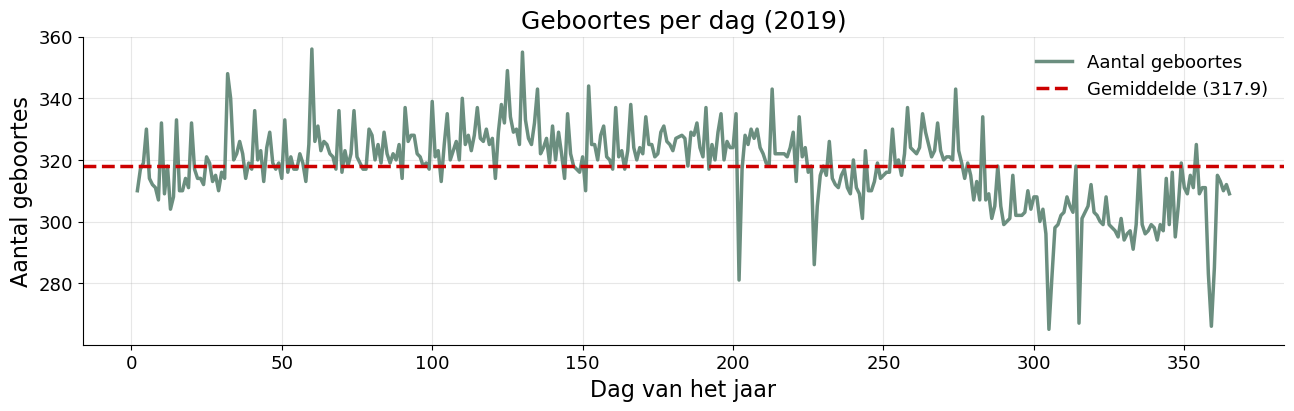

In [191]:
daily_clean = (
    df_births_clean
    .groupby("dag_van_jaar", as_index=False)
    .size()
    .rename(columns={"size": "geboortes"})
    .sort_values("dag_van_jaar")     
)

gemiddelde_geboortes = daily_clean["geboortes"].mean()

fig, ax = plt.subplots(figsize=(15.5, 4))
ax.plot(daily_clean["dag_van_jaar"], daily_clean["geboortes"], label = "Aantal geboortes")

ax.set_title("Geboortes per dag (2019)")
ax.set_xlabel("Dag van het jaar")
ax.set_ylabel("Aantal geboortes")

# 1) Set y-limits (bottom ≈ 250, top ≈ 360)
ax.set_ylim(260, 360)

# 2) Build tick list: ensure 280 is present, then the rest every 10 up to 360
ticks = list(range(280, 361, 20))

# 3) Apply ticks & integer formatting
ax.set_yticks(ticks)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%d'))

ax.grid(True, alpha=0.3)

# Horizontal dashed mean line
ax.axhline(
    y=gemiddelde_geboortes,
    color=MEAN_COLOR,
    linestyle="--",
    label=f"Gemiddelde ({gemiddelde_geboortes:.1f})"
)

ax.legend()
plt.show()

#### Vraag 2.3 Identificeer de **8 meest extreme** dagen in de tweede helft van het jaar. (1 pnt)

In [192]:
start = pd.Timestamp(f"2019-01-01")

# Controleer daily_clean
assert daily_clean["dag_van_jaar"].between(1, 365).all(), "dag_van_jaar buiten [1..365]"
assert daily_clean["dag_van_jaar"].is_unique, "dag_van_jaar bevat duplicaten"

# 2) Voeg datum (geboortedatum) toe aan daily_clean
daily_clean_df = daily_clean.assign(
    geboortedatum = start + pd.to_timedelta(daily_clean["dag_van_jaar"] - 1, unit="D")
)

# Kolomvolgorde als in oplossing
daily_clean_df = daily_clean_df[["geboortedatum", "dag_van_jaar", "geboortes"]]

# Filter enkel tweede helft van het jaar (sem2)
start = pd.Timestamp("2019-07-01")
sem2 = daily_clean_df[daily_clean_df[COL_GEBOORTEDATUM] >= start]     

# 8 laagste dagtotalen, + nette kolommen met assign
extreme8 = sem2.nsmallest(8, "geboortes").sort_values("geboortedatum", ascending = True) #de 8 kleinste, in oplossing zijn het de kleinste uitschieters

display(extreme8)


,geboortedatum,dag_van_jaar,geboortes
199,2019-07-21,202,281
224,2019-08-15,227,286
302,2019-11-01,305,265
303,2019-11-02,306,282
312,2019-11-11,315,267
355,2019-12-24,358,283
356,2019-12-25,359,266
357,2019-12-26,360,285


### Vraag 3: Verbanden per week/maand

#### Vraag 3.1 (2 pnt)
We zien vele pieken en dalen in de evolutie van het aantal geboortes. We willen deze grafiek graag iets "gladder" maken. Kan je hiervoor eens een visualizatie maken van het **gemiddeld** aantal geboortes per week (dit voor elke week, dus maandag-maandag, dinsdag-dinsdag, woensdag-woensdag, ...).


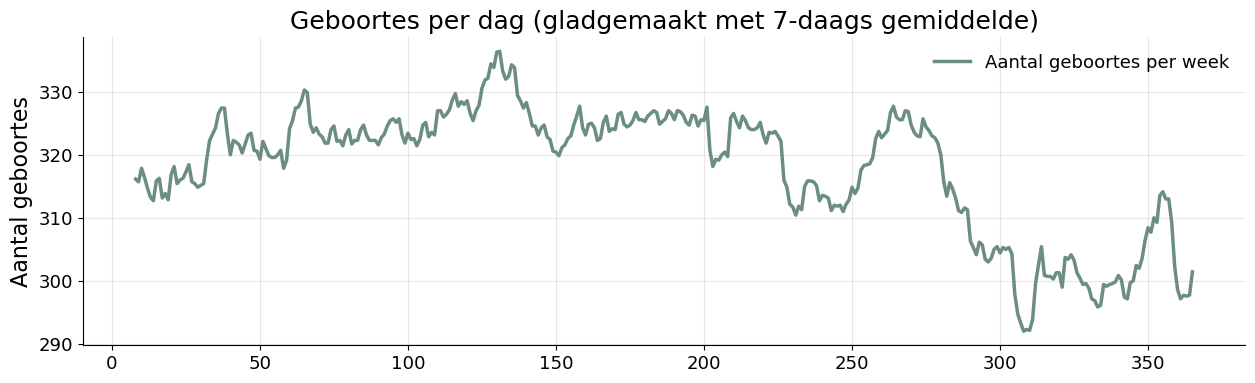

In [193]:
s = (df_births_clean
     .groupby(COL_DAG_VAN_HET_JAAR)
     .size()
     .rename("geboortes")
     .sort_index()
)
# 7-daags rolling average (gecentreerd)
ra7 = s.rolling(window=7).mean()
#  , center=True, min_periods=3 wat is het verschil 

fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(ra7.index, ra7.values, label="Aantal geboortes per week")
ax.set(title="Geboortes per dag (gladgemaakt met 7-daags gemiddelde)", ylabel="Aantal geboortes")
ax.grid(True, alpha=0.3); ax.legend()
plt.show()

#### Vraag 3.2 (2 pnt)
Dat ziet er al een stuk mooier uit!  We zien ook een aantal duidelijk dips & pieken verschijnen die we eerder niet zagen. We kunnen nu ook even kijken naar het gemiddeld aantal geboortes per dag van de week! Misschien worden er wel gewoon veel minder mensen geboren op zondag dan een andere dag?

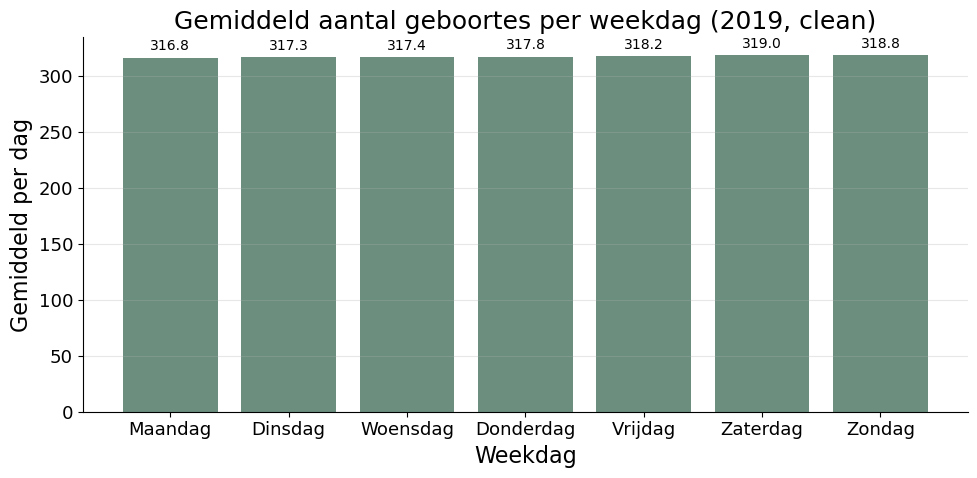

In [194]:
# Weekdagnaam uit kolom
try:
    daily_clean_df["weekdag_naam"] = daily_clean_df["geboortedatum"].dt.day_name(locale="nl_BE")
except Exception:
    daily_clean_df["weekdag_naam"] = daily_clean_df["geboortedatum"].dt.dayofweek.map({
        0:"Maandag",1:"Dinsdag",2:"Woensdag",3:"Donderdag",4:"Vrijdag",5:"Zaterdag",6:"Zondag"
    })

# Gemiddelde per weekdag
means = (daily_clean_df
         .groupby("weekdag_naam", as_index=True)["geboortes"]
         .mean()
         .reindex(["Maandag","Dinsdag","Woensdag","Donderdag","Vrijdag","Zaterdag","Zondag"]))

# Plot
fig, ax = plt.subplots()
bars = ax.bar(means.index, means.values, color=SAGE)
#  bars = means.plot(kind="bar", ax=ax) dit was het oorspronkelijke voorstel, waarom werkt dit nu niet meer als ik die labels wil toevoegen

ax.bar_label(bars, labels=[f"{v:.1f}" for v in means.values],
             padding=3, fontsize=10, color="black")

ax.set_title("Gemiddeld aantal geboortes per weekdag (2019, clean)")
ax.set_xlabel("Weekdag")
ax.set_ylabel("Gemiddeld per dag")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


#### Vraag 3.3 — Maandverschillen in geboortes (3pnt)

Je beschikt over geboortecijfers per dag voor één kalenderjaar.

Maak één visualisatie die het gemiddeld aantal geboortes per maand toont
en tegelijk toelaat om de variatie binnen elke maand te vergelijken.

De visualisatie moet:
- de maanden tonen in chronologische volgorde (januari → december)
- per maand het gemiddelde aantal geboortes tonen
- per maand de onzekerheid rond dat gemiddelde tonen op 95% betrouwbaarheid en gebaseerd op de dagwaarden (niet handmatig berekend)



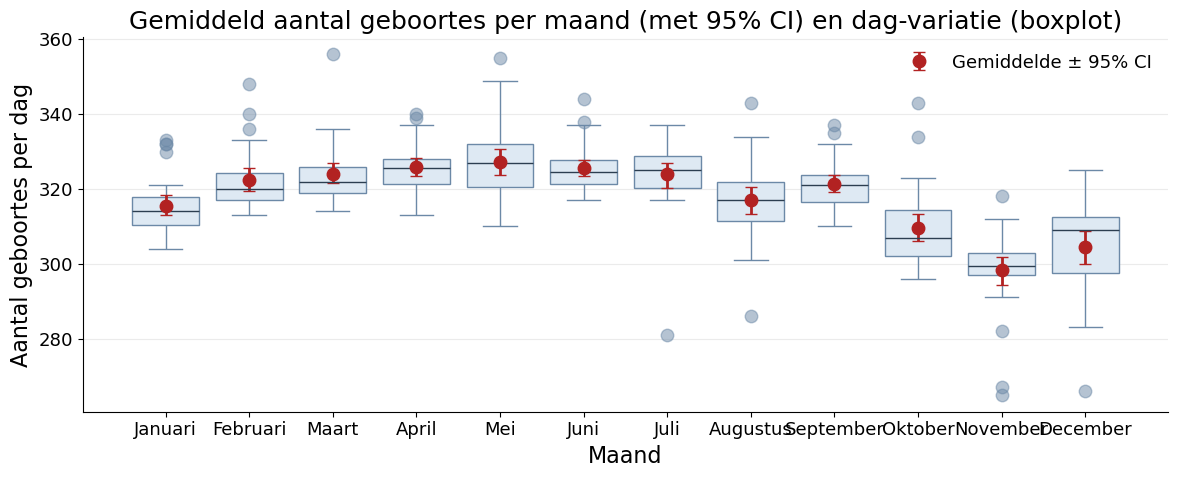

In [ ]:
# -----------------------------
# 1) Dagtotalen bouwen uit de ruwe rijen
# -----------------------------
df = df_births_clean.copy()
df[COL_GEBOORTEDATUM] = pd.to_datetime(df[COL_GEBOORTEDATUM], errors="raise")

# Dagelijks aantal geboortes
daily = (df.groupby(df[COL_GEBOORTEDATUM].dt.date, as_index=False)
           .size()
           .rename(columns={"date": COL_GEBOORTEDATUM, "size": "geboortes"}))

# Voeg maand-helpers toe
daily[COL_GEBOORTEDATUM] = pd.to_datetime(daily[COL_GEBOORTEDATUM])
daily["month_num"]  = daily[COL_GEBOORTEDATUM].dt.month
daily["month_name"] = daily[COL_GEBOORTEDATUM].dt.month_name(locale="nl_BE") if hasattr(daily[COL_GEBOORTEDATUM].dt, "month_name") else \
                      daily[COL_GEBOORTEDATUM].dt.month.map({1:"Januari",2:"Februari",3:"Maart",4:"April",5:"Mei",6:"Juni",
                                                    7:"Juli",8:"Augustus",9:"September",10:"Oktober",11:"November",12:"December"})

# -----------------------------
# 2) Bootstrap 95% CI per maand (op basis van DAGWAARDEN)
#    - Niet handmatig, volledig uit data berekend
# -----------------------------
def bootstrap_mean_ci(x, n_boot=5000, ci=0.95, random_state=42):
    rng = np.random.default_rng(random_state)
    x = np.asarray(x, dtype=float)
    boot = rng.choice(x, size=(n_boot, x.size), replace=True).mean(axis=1)
    lower = np.quantile(boot, (1-ci)/2)
    upper = np.quantile(boot, 1-(1-ci)/2)
    return x.mean(), lower, upper

ci_rows = []
for m, grp in daily.groupby("month_num"):
    mu, lo, hi = bootstrap_mean_ci(grp["geboortes"].values, n_boot=5000, ci=0.95, random_state=2024+m)
    ci_rows.append({
        "month_num": m,
        "month_name": grp["month_name"].iloc[0],
        "mean": mu,
        "ci_low": lo,
        "ci_high": hi
    })

ci_df = (pd.DataFrame(ci_rows)
           .sort_values("month_num")
           .reset_index(drop=True))

# -----------------------------
# 3) Visualisatie:
#    - Boxplot per maand (dagwaarden) => variatie zichtbaar
#    - Overlay: punt = maandgemiddelde + errorbar = 95% CI
#    - Maanden in chronologische volgorde
# -----------------------------
order_names = ci_df["month_name"].tolist()  # Jan -> Dec

fig, ax = plt.subplots(figsize=(12, 5))

# Boxplots per maand (dagelijks aantal geboortes)
sns.boxplot(
    data=daily,
    x="month_name",
    y="geboortes",
    order=order_names,
    ax=ax,
    color="#dbe9f6",
    boxprops=dict(edgecolor="#6c89a7"),
    medianprops=dict(color="#2c3e50"),
    whiskerprops=dict(color="#6c89a7"),
    capprops=dict(color="#6c89a7"),
    flierprops=dict(markerfacecolor="#6c89a7", markeredgecolor="#6c89a7", alpha=0.5)
)

# Overlay: mean + 95% CI (errorbars)
xpos = np.arange(len(ci_df))
ax.errorbar(
    xpos, ci_df["mean"],
    yerr=[ci_df["mean"] - ci_df["ci_low"], ci_df["ci_high"] - ci_df["mean"]],
    fmt="o", color="#b22222", ecolor="#b22222", elinewidth=2, capsize=4, label="Gemiddelde ± 95% CI"
)

# X-as omzetten naar de maandlabels op dezelfde posities
ax.set_xticks(xpos, order_names, rotation=0)

ax.set_title("Gemiddeld aantal geboortes per maand (met 95% CI) en dag-variatie (boxplot)")
ax.set_xlabel("Maand")
ax.set_ylabel("Aantal geboortes per dag")
ax.grid(axis="y", alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()

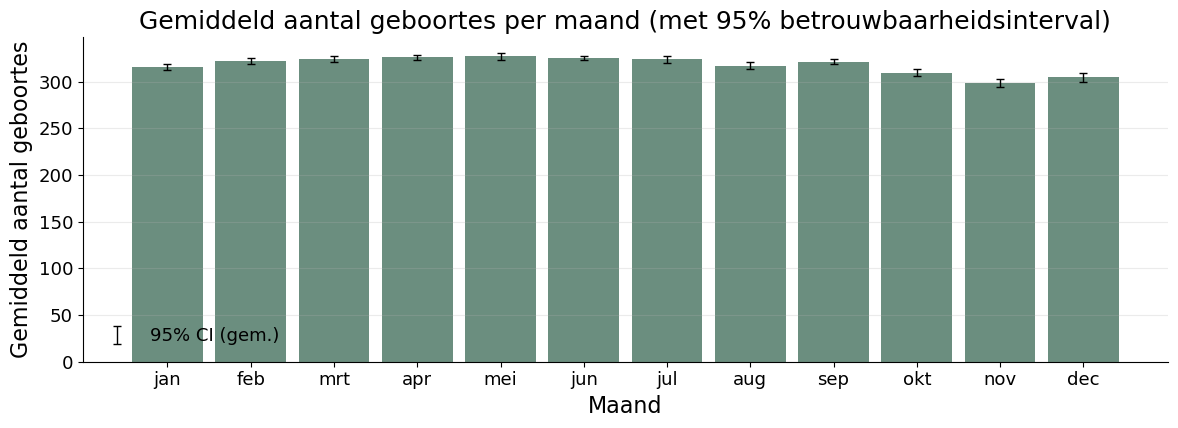

In [196]:
# 1) Dagtotalen (één waarde per kalenderdag)
daily = (df_births_clean
         .groupby(df_births_clean[COL_GEBOORTEDATUM].dt.date, as_index=False)  # geen her-assign; gebruik de bestaande kolom
         .size()
         .rename(columns={"date": COL_GEBOORTEDATUM, "size": "geboortes"}))

# Terug naar Timestamp voor makkelijke .dt accessor
daily[COL_GEBOORTEDATUM] = pd.to_datetime(daily[COL_GEBOORTEDATUM])

# 2) Maandgemiddelde + 95% CI (t-interval) op basis van DAGWAARDEN
try:
    from scipy.stats import t
    def tcrit(n):
        return t.ppf(0.975, df=n-1) if n > 1 else np.nan
except Exception:
    # Fallback: normal approximation (n≈30 → vrijwel gelijk)
    def tcrit(n):
        return 1.96 if n > 1 else np.nan

# Nederlandse afkortingen (zoals je vroeg)
month_short_nl = {1:"jan", 2:"feb", 3:"mrt", 4:"apr", 5:"mei", 6:"jun",
                  7:"jul", 8:"aug", 9:"sep", 10:"okt", 11:"nov", 12:"dec"}

monthly = (daily
           .assign(month_num = daily[COL_GEBOORTEDATUM].dt.month)
           .groupby("month_num", as_index=False)["geboortes"]
           .agg(n="count", mean="mean", std="std"))

monthly["sem"]   = monthly["std"] / np.sqrt(monthly["n"])
monthly["tcrit"] = monthly["n"].apply(tcrit)
monthly["ci_low"]  = monthly["mean"] - monthly["tcrit"] * monthly["sem"]
monthly["ci_high"] = monthly["mean"] + monthly["tcrit"] * monthly["sem"]

monthly["month_label"] = monthly["month_num"].map(month_short_nl)
monthly = monthly.sort_values("month_num")

# 3) Plot: bars + 95% CI (geen kleuren ingesteld → jouw styling.py bepaalt het thema)
x = np.arange(len(monthly))
y = monthly["mean"].values
yerr = np.vstack([y - monthly["ci_low"].values, monthly["ci_high"].values - y])

fig, ax = plt.subplots(figsize=(12, 4.5))

bars = ax.bar(x, y, width=0.85)  # geen color=
ax.errorbar(x, y, yerr=yerr, fmt="none", ecolor="black",
            elinewidth=1, capsize=3, zorder=3, label="95% CI (gem.)")

ax.set_xticks(x, monthly["month_label"].tolist())
ax.set_title("Gemiddeld aantal geboortes per maand (met 95% betrouwbaarheidsinterval)")
ax.set_xlabel("Maand")
ax.set_ylabel("Gemiddeld aantal geboortes")
ax.grid(axis="y", alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()

#### Vraag 3.2 Weekdag en seizoen (4 pnt)

Je beschikt over geboortecijfers per dag voor één kalenderjaar.

Onderzoek of het effect van de dag van de week op het aantal geboortes constant is doorheen het jaar of verschilt naargelang het seizoen.

Maak één visualisatie die:
- verschillen tussen weekdagen toont
- toelaat om deze verschillen over het jaar te vergelijken
- leesbaar blijft zonder aparte grafieken per maand of weekdag



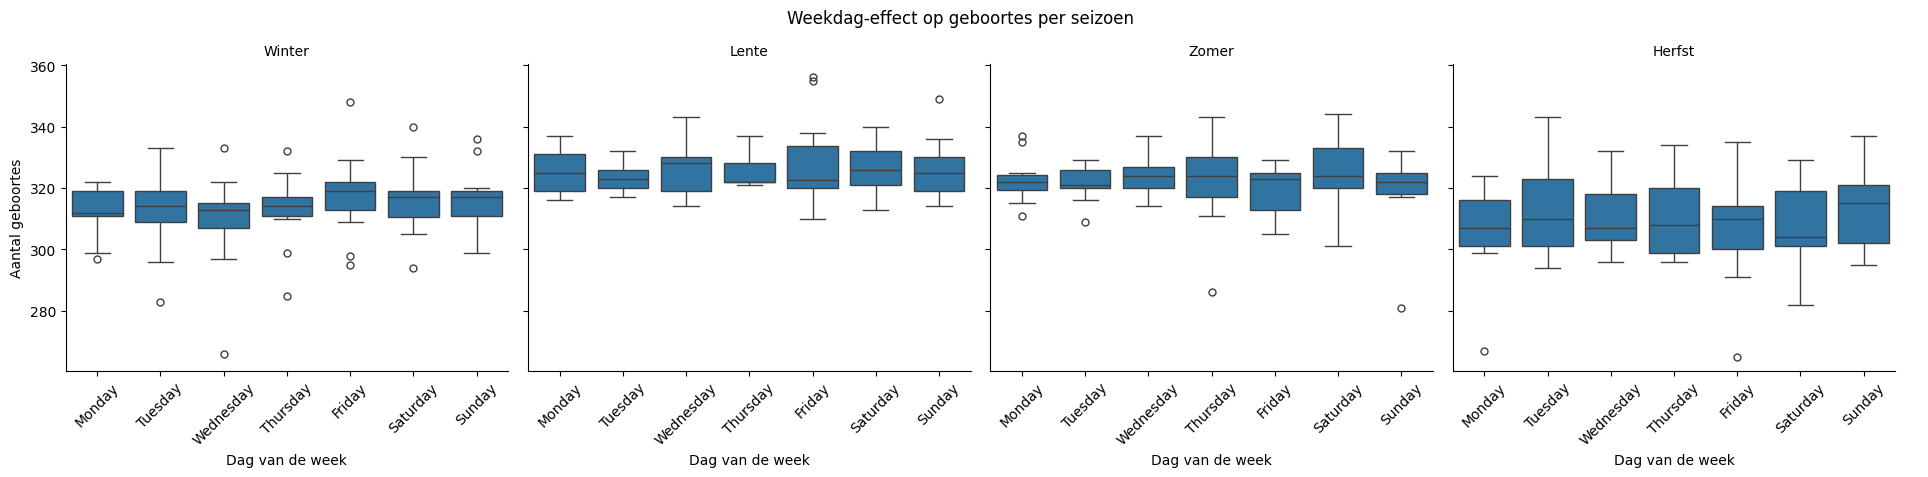

## Stap 3: Onderzoeksvragen


### Onderzoek 1: Unisex namen


#### Vraag 1.1 (3pnt)
Je wil namen identificeren die zowel bij jongens als bij meisjes voorkomen.
Construeer een tabel `df_name_gender` met exact één rij per naam, waarin je het totaal aantal geboortes voor jongens, voor meisjes en in totaal opneemt.

Rapporteer het aantal namen dat bij beide geslachten voorkomt en geef voor deze groep telkens de drie namen met het hoogste aantal jongensgeboortes, meisjesgeboortes en totale geboortes. Licht kort toe of en waarom je zeldzame namen al dan niet meeneemt in de analyse.


Populairse unisex naam bij de mannen: Maxime
Populairse unisex naam bij de vrouwen: Dominique
Populairse unisex naam in het algemeen: Dominique


#### Vraag 1.2 (2 pnt)

Niet alle namen die bij beide geslachten voorkomen, zijn evenwichtig verdeeld. In deze oefening beschouwen we een naam als “echt unisex” wanneer het aantal geboortes bij het ene geslacht niet meer dan 50% hoger ligt dan bij het andere. Concreet geldt voor een naam met `x` mannen en `y` vrouwen dat deze als echt unisex wordt beschouwd wanneer `x <= 1.5 * y` en `y <= 1.5 * x`.

Pas deze definitie toe op je unisex dataset en construeer een DataFrame `df_real_unisex` dat uitsluitend deze echte unisex namen bevat.

Beantwoord vervolgens opnieuw de drie vragen uit de vorige oefening voor deze dataset.


Populairse echte unisex naam bij de mannen: Dominique
Populairse echte unisex naam bij de vrouwen: Dominique
Populairse echte unisex naam in het algemeen: Dominique


#### Vraag 1.3 (1 pnt)
Ga na of echte unisex namen relatief populairder zijn bij mannen of bij vrouwen, of dat de populariteit tussen beide geslachten vergelijkbaar is. Hiervoor kan je vertrekken van het percentage mannen en vrouwen dat een echte unisex naam draagt.

Percentage mannen met unisex naam: 0.4%
Percentage vrouwen met unisex naam: 0.5%


#### Vraag 1.4 (2 pnt)

Maak een visualizatie die alle echte unisex namen toont en de relatieve voorkomens bij mannen en vrouwen.

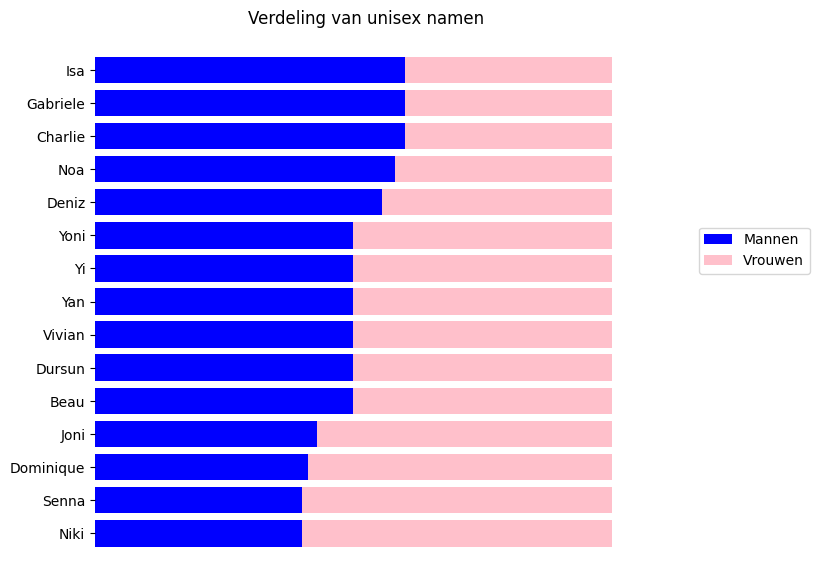

### Onderzoek 2: de accuraatheid van de geschatte bevallingsdatum


### Vraag 2.1 Evolutie vergelijken (3pnt)

Maak één figuur waarin je het totale aantal effectieve geboortes per dag en het totale aantal verwachte geboortes per dag samen weergeeft over de tijd.

Zorg ervoor dat beide reeksen op een eerlijke en vergelijkbare manier worden getoond.


(150.0, 380.0)

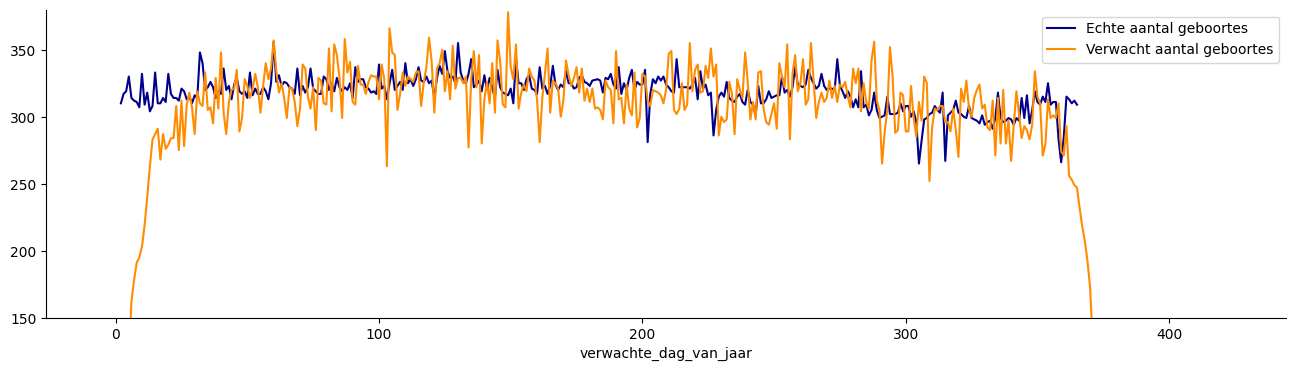

#### Vraag 2.2 (1 pnt)
De figuur vertoont aan het begin en het einde van het jaar een afwijkend patroon. Beschrijf kort waarom dit gebeurt en noteer je verklaring in een comment

### Vraag 2.3 (3 pnt)

Voor het jaar 2019 wil je analyseren hoe vroeg baby’s effectief geboren worden ten opzichte van hun verwachte geboortedatum.

Definieer een foutmaat die het verschil uitdrukt tussen de effectieve en de verwachte geboortedag, waarbij positieve waarden overeenkomen met een geboorte vóór de verwachte datum. Beperk je analyse tot geboortes die effectief te vroeg plaatsvinden en visualiseer de verdeling van deze foutmaat voor 2019 in een histogram. Kies het aantal bins expliciet en motiveer kort waarom deze keuze geschikt is.

Duid in het histogram zowel de mediaan als het 90e percentiel van het aantal dagen te vroeg expliciet aan.


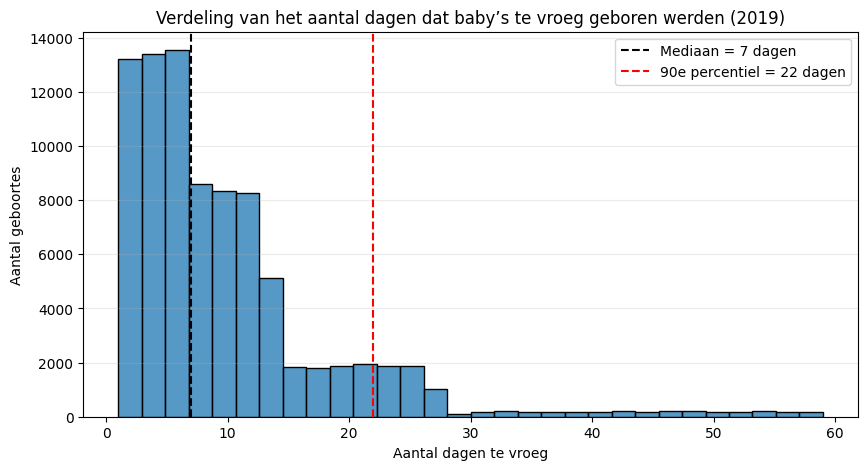

### Vraag 2.4 (4 pnt)

Voor het jaar 2019 wil je nagaan hoe goed de verwachte geboortedag overeenkomt met de effectieve geboortedag, maar je wil dit nu enkel doen voor de acht gemeenten met het hoogste aantal geboortes.

Bepaal eerst welke acht gemeenten in 2019 de meeste geboortes tellen. Visualiseer vervolgens, voor deze acht gemeenten, de relatie tussen de effectieve dag van het jaar en de verwachte dag van het jaar in een scatterplot per gemeente, zodat je kan vergelijken of de accuraatheid verschilt tussen gemeenten.

Gebruik in alle deelplots dezelfde schaal op beide assen en voeg een referentielijn toe die een perfecte schatting voorstelt.


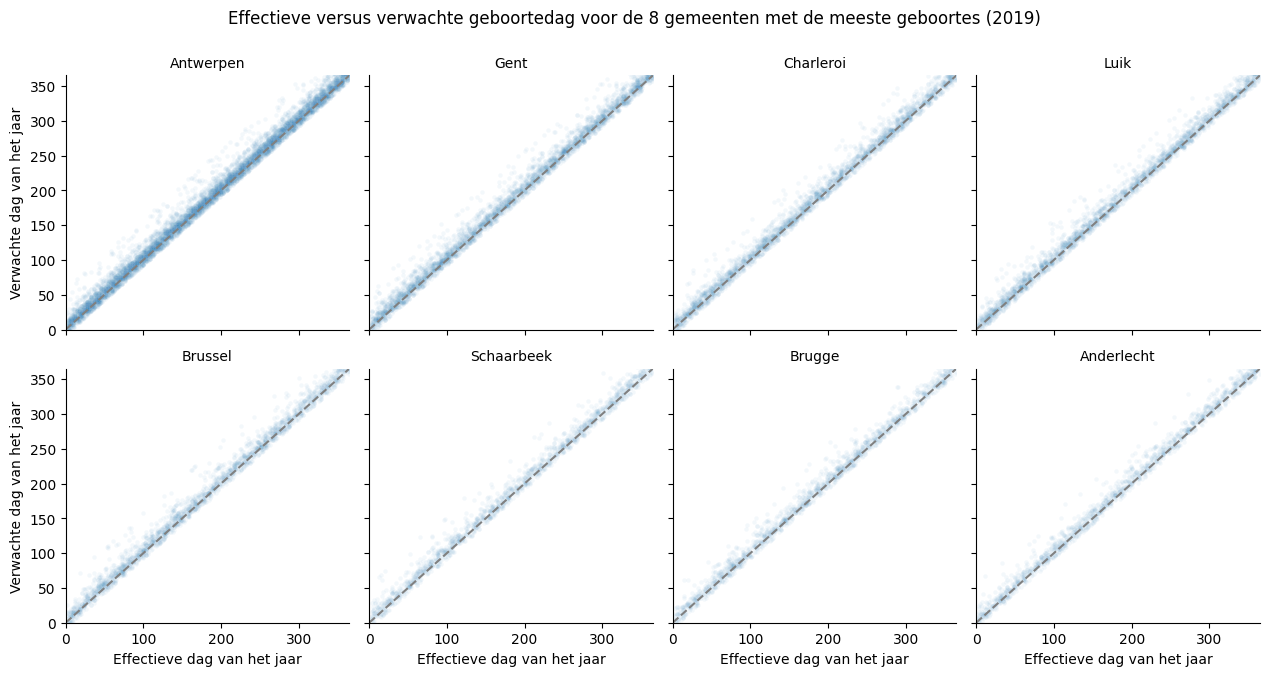

### Onderzoek 3: Aantal namen versus aantal babies

#### Vraag 3.1

Wanneer er meer baby’s geboren worden, verwachten we ook meer verschillende namen te observeren. Bij lage aantallen geboortes lijkt het aannemelijk dat dit verband ongeveer lineair is, maar bij grotere aantallen wordt het minder vanzelfsprekend dat het aantal unieke namen in dezelfde mate blijft toenemen. We verwachten bijvoorbeeld niet dat het aantal unieke namen bij twee miljoen geboortes dubbel zo groot is als bij één miljoen geboortes.

Onderzoek op basis van deze dataset het verband tussen het aantal baby’s en het aantal unieke namen. Je krijgt geen suggestie voor een specifieke visualisatie en kiest zelf hoe je dit verband het best aantoont.

Onderbouw je antwoord met minstens één visualisatie en bijkomende analyse waar nodig. Probeer niet enkel te beschrijven wat je ziet, maar overtuig waarom jouw conclusie logisch is gegeven de data en waarom een lineair verband al dan niet houdbaar blijft over het volledige bereik.


(0.0, 7000.0)

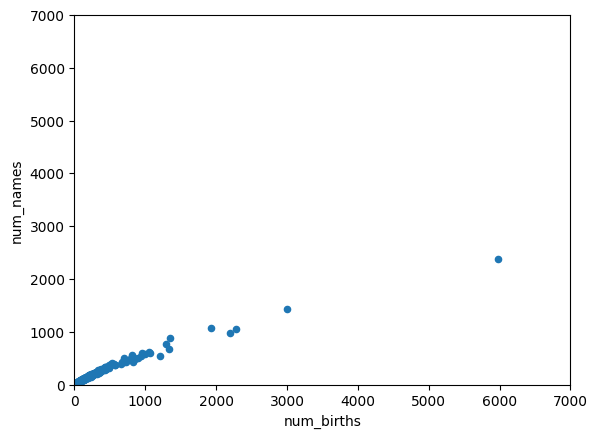

#### Met random sampling

We nemen een aantal punten waarop we samples trekken 

100%|██████████| 100/100 [00:02<00:00, 45.45it/s]


We bekijken eerst rechstreeks het verband waar we geinteresseerd in zijn. Dit verband lijkt eerst sterk te stijgen maar vanaf 40 000 geboortes vlakt de stijging sterk af. Het verband is zeker niet linear, hoewel we vanaf de 40 000 wel van een min of meer lineair verband kunnen spreken. Om de rechte verder door te trekken, hebben we een grotere dataset nodig.

<Axes: xlabel='n_births', ylabel='num_names'>

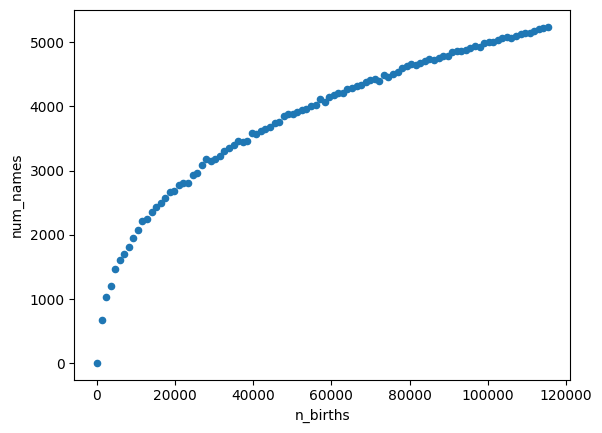

Een afgeleide variabele (die misschien wel interessanter is) is de frequentie van elke naam als functie van het aantal geboortes. Als we deze variabele nemen, zien we vrij snel een lineair verband ontstaan (hoewel voor minder dan 10 000 geboortes het verband niet echt lineair is). We kunnen dit verband tonen en een lineaire rechte fitten op het gedeelte met meer dan 10 000 geboortes.

<Axes: xlabel='n_births', ylabel='freq_names'>

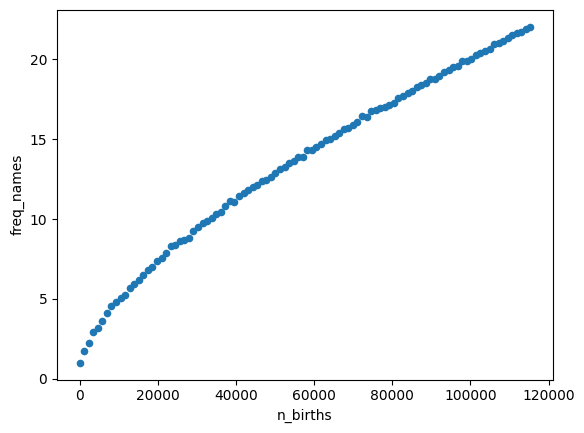

### Lineaire regressie
We doen nu een lineaire regressie op de data voor `n_births > 10 000`

Intercept: 4.65287178674086
Coefficient: 0.0001563408784655592


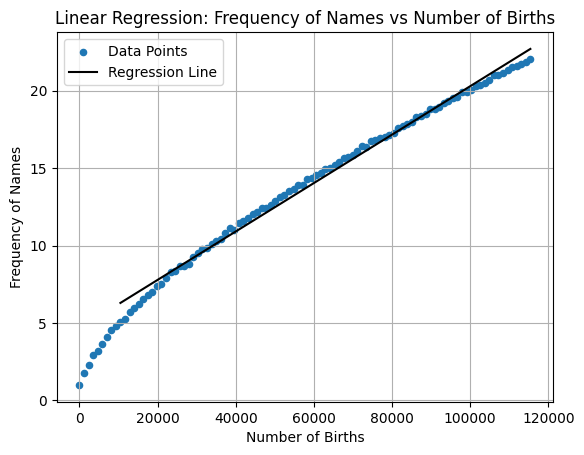

### Transformatie voor lineaire regressie

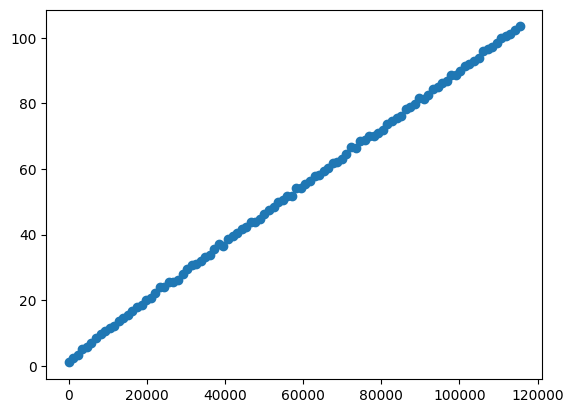

### Validatie plots
#### Valideer de accuraatheid van de frequency names 

<Axes: xlabel='n_births', ylabel='freq_names'>

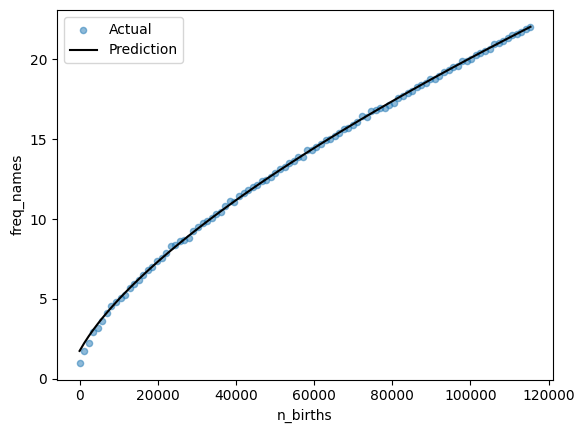

#### Valideer nu hetzelfde model zijn voorspellingen van totaal aantal verschillende namen

<Axes: xlabel='n_births', ylabel='num_names'>

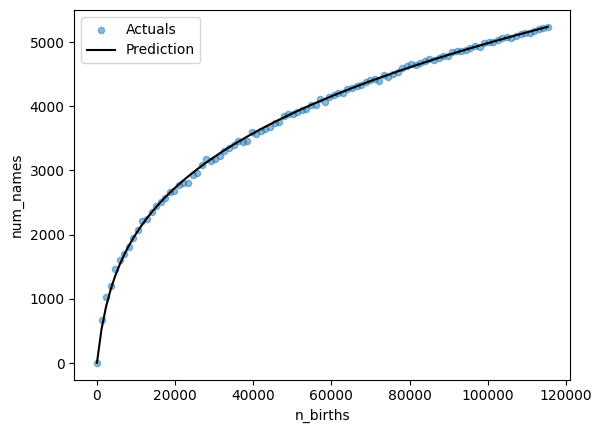